<a href="https://colab.research.google.com/github/usbrendonb/Python/blob/AI_Class/AI_Computer_Vision_Day_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Computer vision in marketing and web development (upload picture to google and it says its a dog...etc)
# Teaching a computer to Images
# Image Recognition
# Product Tagging
#


In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [3]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 871s 5us/step


In [5]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

In [7]:
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

In [8]:
print("Training Images : ", X_train.shape)
print("Training Labels : ", y_train.shape)

print("Testing Images : ", X_test.shape)
print("Testing Labels : ", y_test.shape)

Training Images :  (50000, 32, 32, 3)
Training Labels :  (50000, 1)
Testing Images :  (10000, 32, 32, 3)
Testing Labels :  (10000, 1)


<function matplotlib.pyplot.show(close=None, block=None)>

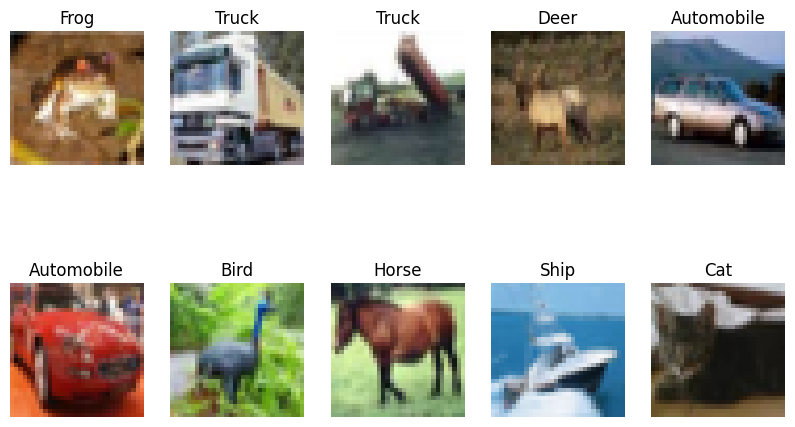

In [12]:
plt.figure(figsize=(10,6))

for i in range (10):
  plt.subplot(2,5,i+1)
  plt.imshow(X_train[i])
  plt.title(class_names[y_train[i][0]])
  plt.axis("off")
plt.show

In [13]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [14]:

model = models.Sequential()

# First Convolution Layer
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))

# Pooling Layer
model.add(layers.MaxPooling2D((2,2)))

# Second Convolution Layer
model.add(layers.Conv2D(64, (3,3), activation='relu'))

# Second Pooling Layer
model.add(layers.MaxPooling2D((2,2)))

# Flatten
model.add(layers.Flatten())

# Hidden Layer
model.add(layers.Dense(64, activation='relu'))

# Output Layer
model.add(layers.Dense(10, activation='softmax'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_data=(X_test,y_test)
)

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 38ms/step - accuracy: 0.1877 - loss: 2.1669 - val_accuracy: 0.2739 - val_loss: 2.0178
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 36ms/step - accuracy: 0.2815 - loss: 1.9986 - val_accuracy: 0.2981 - val_loss: 1.9673
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 38ms/step - accuracy: 0.3024 - loss: 1.9487 - val_accuracy: 0.3115 - val_loss: 1.9241
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 60s 38ms/step - accuracy: 0.3159 - loss: 1.9077 - val_accuracy: 0.3330 - val_loss: 1.8809
Epoch 5/50
 607/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 36ms/step - accuracy: 0.3263 - loss: 1.8878

KeyboardInterrupt: 

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

In [ ]:
predictions = model.predict(X_test)

In [ ]:

plt.figure(figsize=(10,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[i])

    predicted = np.argmax(predictions[i])

    actual = y_test[i][0]

    plt.title(f"P:{class_names[predicted]}\nA:{class_names[actual]}")

    plt.axis("off")

plt.show()

In [ ]:
model.save("Image_Classifier_Model.h5")